In [37]:
from datasets import load_dataset
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt 


In [3]:
# Pre-computed DINOv2 + ConvNeXt embeddings on JWST/HSC crossmatch
ds = load_dataset("UniverseTBD/jwst_hsc_embeddings", split="train")

# Filter the entire dataset to remove rows where the embeddings are missing
ds = ds.filter(lambda row: row['dino_base_jwst'] is not None)


In [5]:
ds

Dataset({
    features: ['jwst_object_id', 'astropt_15m_hsc', 'astropt_15m_jwst', 'astropt_95m_hsc', 'astropt_95m_jwst', 'astropt_850m_hsc', 'astropt_850m_jwst', 'convnext_nano_hsc', 'convnext_nano_jwst', 'convnext_tiny_hsc', 'convnext_tiny_jwst', 'convnext_base_hsc', 'convnext_base_jwst', 'convnext_large_hsc', 'convnext_large_jwst', 'dino_small_hsc', 'dino_small_jwst', 'dino_base_hsc', 'dino_base_jwst', 'dino_large_hsc', 'dino_large_jwst', 'dino_giant_hsc', 'dino_giant_jwst', 'ijepa_huge_hsc', 'ijepa_huge_jwst', 'ijepa_giant_hsc', 'ijepa_giant_jwst', 'vit_base_hsc', 'vit_base_jwst', 'vit_large_hsc', 'vit_large_jwst', 'vit_huge_hsc', 'vit_huge_jwst'],
    num_rows: 1496
})

In [28]:
def MKNN(d1: np.array, d2: np.array, k: int) -> float:
    #find all k-sims
    knn_1 = NearestNeighbors(n_neighbors =k, metric = "cosine").fit(d1)
    knn_2 = NearestNeighbors(n_neighbors =k, metric = "cosine").fit(d2)
    knn_1 = knn_1.kneighbors(return_distance = False)
    knn_2 = knn_2.kneighbors(return_distance = False)

    matches = []
    for i in range(knn_1.shape[0]): 
        matches.append(len(np.intersect1d(knn_1[i], knn_2[i])))
    return np.sum(matches)/ (float(knn_1.shape[0])*k)


In [ ]:
names = list(ds.features.keys())[1:]
names_jwst = [ name for name in names if name.endswith("jwst")]


names_hsc = [ name for name in names if name.endswith("hsc")]



In [24]:
%%capture
hsc_pairs = {}
for i in range(1, len(names_hsc)):
    if(names_hsc[i].split('_')[0] == names_hsc[i-1].split('_')[0]):
        hsc_pairs[f"{names_hsc[i-1]} vs {names_hsc[i]}"] =  MKNN(ds[names_hsc[i-1]], ds[names_hsc[i]] ,10)
print(hsc_pairs)
  

    

In [25]:
%%capture
jwst_pairs = {}
for i in range(1, len(names_jwst)):
    if(names_jwst[i].split('_')[0] == names_jwst[i-1].split('_')[0]):
        jwst_pairs[f"{names_jwst[i-1]} vs {names_jwst[i]}"] =  MKNN(ds[names_jwst[i-1]], ds[names_jwst[i]] ,10)
print(jwst_pairs)


note hsc is not the full large dataset just to save time the only accurate one is jwst to test the correctness of the implmentation and it matches the original paper well 

In [ ]:
data = {
    "hsc": {k.replace("_hsc", ""): v for k, v in hsc_pairs.items()},
    "jwst": {k.replace("_jwst", ""): v for k, v in jwst_pairs.items()}
}
df_hsc = pd.DataFrame(data)
print(df_hsc)


                                      hsc      jwst
astropt_15m vs astropt_95m       0.309559  0.496791
astropt_95m vs astropt_850m      0.358957  0.562299
convnext_nano vs convnext_tiny   0.245388  0.333088
convnext_tiny vs convnext_base   0.241845  0.295388
convnext_base vs convnext_large  0.302406  0.358489
dino_small vs dino_base          0.221390  0.328543
dino_base vs dino_large          0.243783  0.321123
dino_large vs dino_giant         0.332487  0.402005
ijepa_huge vs ijepa_giant        0.240976  0.403275
vit_base vs vit_large            0.224933  0.286832
vit_large vs vit_huge            0.234826  0.326003


/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/abdullah/Pytorch/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


np.float64(1.0)

#cross modal 

In [51]:
%%capture
cross_modal_pairs = {}
for i in range(1, len(names)):
    print(names[i-1].split('_')[0:2])
    if(names[i].split('_')[0:2] == names[i-1].split('_')[0:2]):
        cross_modal_pairs[f"{names[i-1]} vs {names[i]}"] = MKNN(ds[names[i-1]], ds[names[i]] ,10)*100

print(cross_modal_pairs)
  

    

In [ ]:
MODEL_SIZES = {
    # AstroPTv2
    "astropt_15m": 15.0,
    "astropt_95m": 95.0,
    "astropt_850m": 850.0,
    # ConvNeXtv2
    "convnext_nano": 15.0,
    "convnext_tiny": 28.0,
    "convnext_base": 89.0,
    "convnext_large": 198.0,
    # DINOv2
    "dino_small": 22.0,
    "dino_base": 86.0,
    "dino_large": 304.0,
    "dino_giant": 1100.0,
    # IJEPA
    "ijepa_huge": 630.0,
    "ijepa_giant": 1000.0,
    # ViT
    "vit_base": 86.0,
    "vit_large": 304.0,
    "vit_huge": 630.0,
}

In [59]:
list(MODEL_SIZES.values())[11:13]

[630.0, 1000.0]

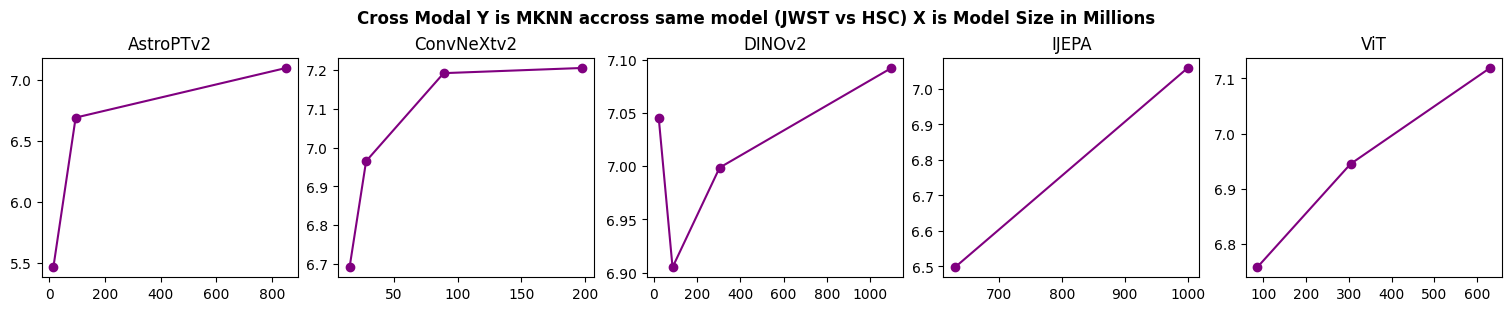

In [69]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15, 3), layout="constrained")
axs[0].plot(list(MODEL_SIZES.values())[0:3], list(cross_modal_pairs.values())[0:3], color='purple', marker = "o")
axs[0].set_title('AstroPTv2')

axs[1].plot(list(MODEL_SIZES.values())[3:7], list(cross_modal_pairs.values())[3:7], color='purple', marker = "o")
axs[1].set_title('ConvNeXtv2')

axs[2].plot(list(MODEL_SIZES.values())[7:11], list(cross_modal_pairs.values())[7:11], color='purple', marker = "o")
axs[2].set_title('DINOv2')

axs[3].plot(list(MODEL_SIZES.values())[11:13], list(cross_modal_pairs.values())[11:13], color='purple', marker = "o")
axs[3].set_title('IJEPA')

axs[4].plot(list(MODEL_SIZES.values())[13:], list(cross_modal_pairs.values())[13:], color='purple', marker = "o")
axs[4].set_title('ViT')
fig.suptitle('Cross Modal Y is MKNN accross same model (JWST vs HSC) X is Model Size in Millions', fontsize=12, fontweight='bold')


plt.show()

This paper is testing the platonic hypothesis but for astro models using the same methodology also consistently hold to the hypothesis cross modal and cross model 